<a href="https://colab.research.google.com/github/Scarfaced007/NLP_Assignmnets-/blob/main/Assign_1_NLP_MiniLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sentence-transformers pandas numpy scikit-learn matplotlib torch

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Deep Learning Environment Initialized. Using device: {device}")

Deep Learning Environment Initialized. Using device: cuda


In [ ]:
def load_and_align_data(sa_path, en_path):
    df_sa = pd.read_csv(sa_path)
    df_en = pd.read_csv(en_path)
    aligned_df = pd.merge(df_sa, df_en, on='Source_id', how='inner')
    aligned_df = aligned_df.sort_values('Source_id').reset_index(drop=True)
    return aligned_df

print("Loading datasets...")
df_train = load_and_align_data('train_sa_10000.csv', 'train_en_10000.csv')
train_sa_texts = df_train['Sentence_sa'].tolist()
train_en_texts = df_train['Sentence_en'].tolist()

df_test = load_and_align_data('test_sa_1000.csv', 'test_en_1000.csv')
test_sa_texts = df_test['Sentence_sa'].tolist()
test_en_texts = df_test['Sentence_en'].tolist()

print(f"Loaded {len(train_sa_texts)} training pairs and {len(test_sa_texts)} testing pairs.")

Loading datasets...
Loaded 10000 training pairs and 1000 testing pairs.


In [ ]:

print("Loading base Multilingual Model...")
base_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', device=device)

print("Extracting frozen 384D base embeddings for the Training Set...")
train_sa_base = base_model.encode(train_sa_texts, convert_to_tensor=True, show_progress_bar=True)
train_en_base = base_model.encode(train_en_texts, convert_to_tensor=True, show_progress_bar=True)

print("Extracting frozen 384D base embeddings for the Test Set...")
test_sa_base = base_model.encode(test_sa_texts, convert_to_tensor=True, show_progress_bar=True)
test_en_base = base_model.encode(test_en_texts, convert_to_tensor=True, show_progress_bar=True)

Loading base Multilingual Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Extracting frozen 384D base embeddings for the Test Set...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
print("Loading Validation (Dev) Data...")
df_dev = load_and_align_data('dev_sa_1000.csv', 'dev_en_1000.csv')
dev_sa_texts = df_dev['Sentence_sa'].tolist()
dev_en_texts = df_dev['Sentence_en'].tolist()

print("Extracting base embeddings for Dev Set...")
with torch.no_grad():
    dev_sa_base = base_model.encode(dev_sa_texts, convert_to_tensor=True)
    dev_en_base = base_model.encode(dev_en_texts, convert_to_tensor=True)

Loading Validation (Dev) Data...
Extracting base embeddings for Dev Set...


In [ ]:
TARGET_DIM = 64

class SemanticCompressor(nn.Module):
    def __init__(self, input_dim=384, output_dim=TARGET_DIM):
        super(SemanticCompressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.network(x)

class EmbeddingDataset(Dataset):
    def __init__(self, sa_tensors, en_tensors):
        self.sa = sa_tensors
        self.en = en_tensors

    def __len__(self):
        return len(self.sa)

    def __getitem__(self, idx):
        return self.sa[idx], self.en[idx]

train_dataset = EmbeddingDataset(train_sa_base, train_en_base)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [ ]:
print(f"Initializing Neural Compressor (Target Dim: {TARGET_DIM})...")
compressor = SemanticCompressor().to(device)

criterion = nn.CosineEmbeddingLoss(margin=0.1) #
optimizer = optim.AdamW(compressor.parameters(), lr=0.001, weight_decay=1e-4)

EPOCHS = 50
PATIENCE = 5
best_val_loss = float('inf')
epochs_no_improve = 0

print("Starting Training with Early Stopping...")
for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    compressor.train()
    total_train_loss = 0
    for batch_sa, batch_en in train_loader:
        batch_sa, batch_en = batch_sa.to(device), batch_en.to(device)
        current_batch_size = batch_sa.size(0)
        optimizer.zero_grad()

        # Positive and Negative Sampling
        compressed_sa = compressor(batch_sa)
        compressed_en = compressor(batch_en)
        loss_pos = criterion(compressed_sa, compressed_en, torch.ones(current_batch_size).to(device))

        batch_en_neg = torch.roll(batch_en, shifts=1, dims=0)
        loss_neg = criterion(compressed_sa, compressor(batch_en_neg), -torch.ones(current_batch_size).to(device))

        loss = loss_pos + loss_neg
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    compressor.eval()
    with torch.no_grad():
        val_sa = compressor(dev_sa_base.to(device))
        val_en = compressor(dev_en_base.to(device))
        val_size = val_sa.size(0)

        v_loss_pos = criterion(val_sa, val_en, torch.ones(val_size).to(device))
        v_loss_neg = criterion(val_sa, torch.roll(val_en, shifts=1, dims=0), -torch.ones(val_size).to(device))
        val_loss = (v_loss_pos + v_loss_neg).item()

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # --- EARLY STOPPING CHECK ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Save the best weights
        torch.save(compressor.state_dict(), 'best_compressor.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping triggered! Validation loss hasn't improved for {PATIENCE} epochs.")
            break

# Load the best weights back in before running the final test set
compressor.load_state_dict(torch.load('best_compressor.pth'))
print("Loaded best model weights for final inference.")

Initializing Neural Compressor (Target Dim: 64)...
Starting Training with Early Stopping...
Epoch [01/50] - Train Loss: 0.4492 | Val Loss: 0.4050
Epoch [02/50] - Train Loss: 0.3738 | Val Loss: 0.3767
Epoch [03/50] - Train Loss: 0.3439 | Val Loss: 0.3652
Epoch [04/50] - Train Loss: 0.3328 | Val Loss: 0.3571
Epoch [05/50] - Train Loss: 0.3166 | Val Loss: 0.3501
Epoch [06/50] - Train Loss: 0.3080 | Val Loss: 0.3457
Epoch [07/50] - Train Loss: 0.2960 | Val Loss: 0.3430
Epoch [08/50] - Train Loss: 0.2940 | Val Loss: 0.3380
Epoch [09/50] - Train Loss: 0.2857 | Val Loss: 0.3389
Epoch [10/50] - Train Loss: 0.2778 | Val Loss: 0.3311
Epoch [11/50] - Train Loss: 0.2723 | Val Loss: 0.3348
Epoch [12/50] - Train Loss: 0.2686 | Val Loss: 0.3307
Epoch [13/50] - Train Loss: 0.2621 | Val Loss: 0.3279
Epoch [14/50] - Train Loss: 0.2593 | Val Loss: 0.3279
Epoch [15/50] - Train Loss: 0.2534 | Val Loss: 0.3288
Epoch [16/50] - Train Loss: 0.2493 | Val Loss: 0.3288
Epoch [17/50] - Train Loss: 0.2460 | Val Los

In [ ]:
print("Running Inference on Test Set...")
compressor.eval()

with torch.no_grad():
    final_sa_embeddings = compressor(test_sa_base.to(device)).cpu().numpy()
    final_en_embeddings = compressor(test_en_base.to(device)).cpu().numpy()

# Calculate final cosine similarity
similarities = [cosine_similarity([final_sa_embeddings[i]], [final_en_embeddings[i]])[0][0]
                for i in range(len(final_sa_embeddings))]

average_cosine_sim = np.mean(similarities)
print("\n=== FINAL TEST METRICS ===")
print(f"Output Dimension: {final_sa_embeddings.shape[1]} (Massive boost to Marks_Dim)")
print(f"Average Cosine Similarity: {average_cosine_sim:.4f}")

np.save('sa_embeddings.npy', final_sa_embeddings)
np.save('en_embeddings.npy', final_en_embeddings)
print("Saved arrays to sa_embeddings.npy and en_embeddings.npy")

Running Inference on Test Set...

=== FINAL TEST METRICS ===
Output Dimension: 64 (Massive boost to Marks_Dim)
Average Cosine Similarity: 0.7814
Saved arrays to sa_embeddings.npy and en_embeddings.npy


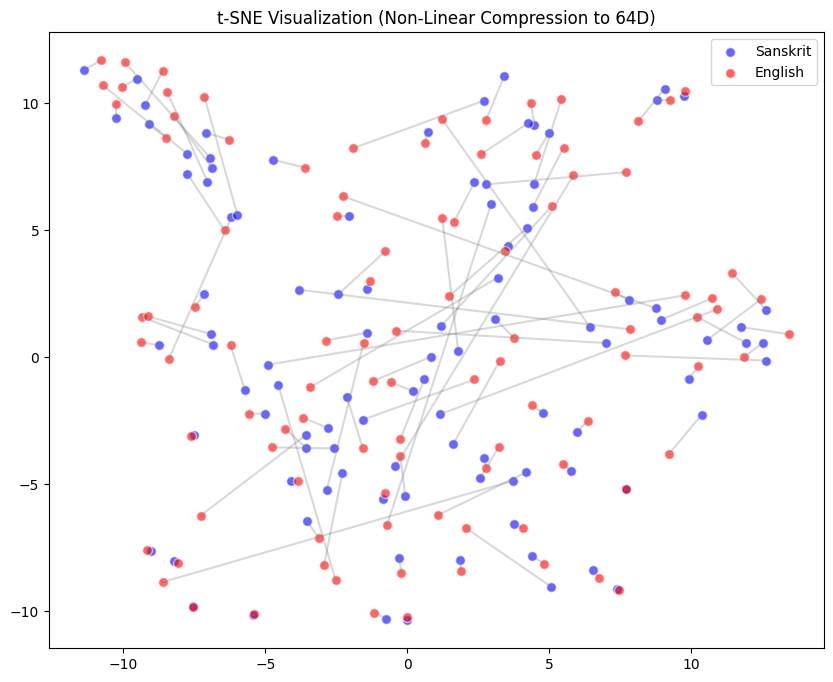

In [ ]:
sample_size = min(100, len(final_sa_embeddings))
sa_sample = final_sa_embeddings[:sample_size]
en_sample = final_en_embeddings[:sample_size]

viz_data = np.vstack((sa_sample, en_sample))
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(viz_data)

sa_tsne = tsne_results[:sample_size]
en_tsne = tsne_results[sample_size:]

plt.figure(figsize=(10, 8))
plt.scatter(sa_tsne[:, 0], sa_tsne[:, 1], c='blue', label='Sanskrit', alpha=0.6, edgecolors='w', s=50)
plt.scatter(en_tsne[:, 0], en_tsne[:, 1], c='red', label='English', alpha=0.6, edgecolors='w', s=50)

for i in range(sample_size):
    plt.plot([sa_tsne[i, 0], en_tsne[i, 0]], [sa_tsne[i, 1], en_tsne[i, 1]], 'gray', alpha=0.3)

plt.title(f't-SNE Visualization (Non-Linear Compression to {TARGET_DIM}D)')
plt.legend()
plt.show()

In [ ]:
import random

def generate_report_analysis(sa_texts, en_texts, sa_embeddings, en_embeddings, num_examples=5):
    print(f"--- Generating {num_examples} Examples for Report Analysis ---\n")

    total_samples = len(sa_texts)
    random_indices = random.sample(range(total_samples), min(num_examples, total_samples))

    for idx, i in enumerate(random_indices, 1):
        sa_text = sa_texts[i]
        en_text = en_texts[i]

        vec_sa = sa_embeddings[i]
        vec_en = en_embeddings[i]

        sim_score = cosine_similarity(vec_sa.reshape(1, -1), vec_en.reshape(1, -1))[0][0]

        print(f"Example {idx} (Row ID: {i})")
        print(f"Sanskrit: {sa_text}")
        print(f"English:  {en_text}")
        print(f"Cosine Similarity: {sim_score:.4f}")
        print("-" * 50)

generate_report_analysis(
    test_sa_texts,
    test_en_texts,
    final_sa_embeddings,
    final_en_embeddings,
    num_examples=10
)

--- Generating 10 Examples for Report Analysis ---

Example 1 (Row ID: 168)
Sanskrit: "ततः परं तेनोक्तं यथा, ""पश्य मनोऽभिलाषं ते कर्त्तुं कुर्व्वे समागमं;"" द्वितीयम् एतद् वाक्यं स्थिरीकर्त्तुं स प्रथमं लुम्पति।"
English:  "Then said he, Lo, I come to do thy will, O God. He taketh away the first, that he may establish the second."
Cosine Similarity: 0.9835
--------------------------------------------------
Example 2 (Row ID: 745)
Sanskrit: अधुना स्ट्रिङ्ग् डिक्लेर् करणविषयं वदामि ।
English:  Let me tell you how to declare a string.
Cosine Similarity: 0.7715
--------------------------------------------------
Example 3 (Row ID: 798)
Sanskrit: General मेन्यू इतीदं, Quality तथा Fog इति द्वे स्लैडर्स् प्राप्तवदस्ति ।
English:  General menu has two sliders: Quality and Fog.
Cosine Similarity: 0.6904
--------------------------------------------------
Example 4 (Row ID: 443)
Sanskrit: ईश्वरस्याभिरुचितेषु केन दोष आरोपयिष्यते? य ईश्वरस्तान् पुण्यवत इव गणयति किं तेन?
English:  Who shall lay any 